# Exploratory Data Analysis (EDA): Spatio-Temporal Fusion Matrix Validation

This notebook performs visual validation and statistical sanity checks on the **Spatio-Temporal Fusion Matrix** (`data/processed/ml_training_matrix.parquet`).

### Objectives
1. **Correlation Assessment**: Verify that our bottom-up physical priors (`brandenburg_wind_prior_mw` and `brandenburg_solar_prior_mw`) strongly correlate with the true 50Hertz macro-targets (`wind_onshore_mw_50hz` and `solar_pv_mw_50hz`).
2. **Temporal Phase Alignment**: Inspect a 14-day time-series slice to ensure that our physical solar prior and the actual 50Hertz targets align precisely in time (e.g., ensuring solar peaks occur exactly at solar noon without timezone offsets/look-ahead errors).
3. **Residual Diagnostic**: Compute residuals (prior discrepancies) for wind generation, and run a correlation analysis against meteorological variables (`temperature_2m`, `surface_pressure`, `relative_humidity_2m`) to understand which features the ML model (LightGBM/TFT) will prioritize to correct the physical priors.

---
## Academic Background & Physics-Informed Priors
By normalising macro targets into Capacity Factors ($CF_t = y_t / C_t$) or scaling up physical priors using regional parameters, we check whether our bottom-up calculations act as a strong baseline predictor. The residual $e_t = y_{target, t} - y_{prior, t}$ represents the portion of power generation that cannot be explained by the simple physical curve model alone, capturing:
- Wake losses and wind turbine arrays interactions.
- Dynamic turbine availability and curtailment events.
- Localized meteorological factors not captured in the simple power curve mapping.


## 1. Imports and Data Loading

First, we import the necessary libraries and load the processed Spatio-Temporal Fusion Matrix from `data/processed/ml_training_matrix.parquet`.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr

# Set plot style for premium aesthetics
sns.set_theme(style="whitegrid", context="talk")
plt.rcParams.update({
    'figure.facecolor': '#f8f9fa',
    'axes.facecolor': '#ffffff',
    'axes.edgecolor': '#cccccc',
    'font.family': 'sans-serif',
    'grid.color': '#eeeeee',
    'grid.linestyle': '--'
})

# Dynamically locate the data file
file_path = '../data/processed/ml_training_matrix.parquet'
if not os.path.exists(file_path):
    file_path = 'data/processed/ml_training_matrix.parquet'

print(f"Loading data from: {file_path}")
df = pd.read_parquet(file_path)

print("Successfully loaded training matrix!")
print(f"Dataframe shape: {df.shape}")
print("\nColumns in the training matrix:")
for col in df.columns:
    print(f" - {col}")
    
# Display first few rows
df.head()

Loading data from: ../data/processed/ml_training_matrix.parquet
Successfully loaded training matrix!
Dataframe shape: (38687, 17)

Columns in the training matrix:
 - wind_onshore_mw_50hz
 - solar_pv_mw_50hz
 - brandenburg_wind_prior_mw
 - brandenburg_solar_prior_mw
 - temperature_2m
 - surface_pressure
 - relative_humidity_2m
 - hour_sin
 - hour_cos
 - month_sin
 - month_cos
 - wind_prior_cf
 - solar_prior_cf
 - wind_eff_capacity_mw
 - solar_eff_capacity_mw
 - wind_cf_50hz
 - solar_cf_50hz


,wind_onshore_mw_50hz,solar_pv_mw_50hz,brandenburg_wind_prior_mw,brandenburg_solar_prior_mw,temperature_2m,surface_pressure,relative_humidity_2m,hour_sin,hour_cos,month_sin,month_cos,wind_prior_cf,solar_prior_cf,wind_eff_capacity_mw,solar_eff_capacity_mw,wind_cf_50hz,solar_cf_50hz
timestamp_utc,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00+00:00,10119.3825,0.0,5663.198802,0.0,11.393488,1009.119302,92.813953,0.000000,1.000000,0.5,0.866025,0.591777,0.0,15418.134013,10681.22375,0.656330,0.0
2022-01-01 01:00:00+00:00,10322.6275,0.0,5622.376458,0.0,11.508140,1009.696279,92.067442,0.258819,0.965926,0.5,0.866025,0.587511,0.0,15418.134013,10681.22375,0.669512,0.0
2022-01-01 02:00:00+00:00,9767.4325,0.0,6184.797066,0.0,11.433256,1010.224884,91.804651,0.500000,0.866025,0.5,0.866025,0.646281,0.0,15418.134013,10681.22375,0.633503,0.0
2022-01-01 03:00:00+00:00,9115.1475,0.0,5832.411347,0.0,11.298372,1010.688605,91.709302,0.707107,0.707107,0.5,0.866025,0.609459,0.0,15418.134013,10681.22375,0.591197,0.0
2022-01-01 04:00:00+00:00,8621.6000,0.0,5448.799211,0.0,11.193721,1011.230000,91.751163,0.866025,0.500000,0.5,0.866025,0.569373,0.0,15418.134013,10681.22375,0.559186,0.0


## 2. Scatter & Correlation Analysis

We construct a 1x2 subplot comparing the bottom-up physical priors against the actual 50Hertz macro-targets.
- **Left Panel**: Wind Onshore Physical Prior vs. 50Hertz actual generation.
- **Right Panel**: Solar PV Physical Prior vs. 50Hertz actual generation.
- A red dashed line ($y = x$) represents a theoretical perfect match.

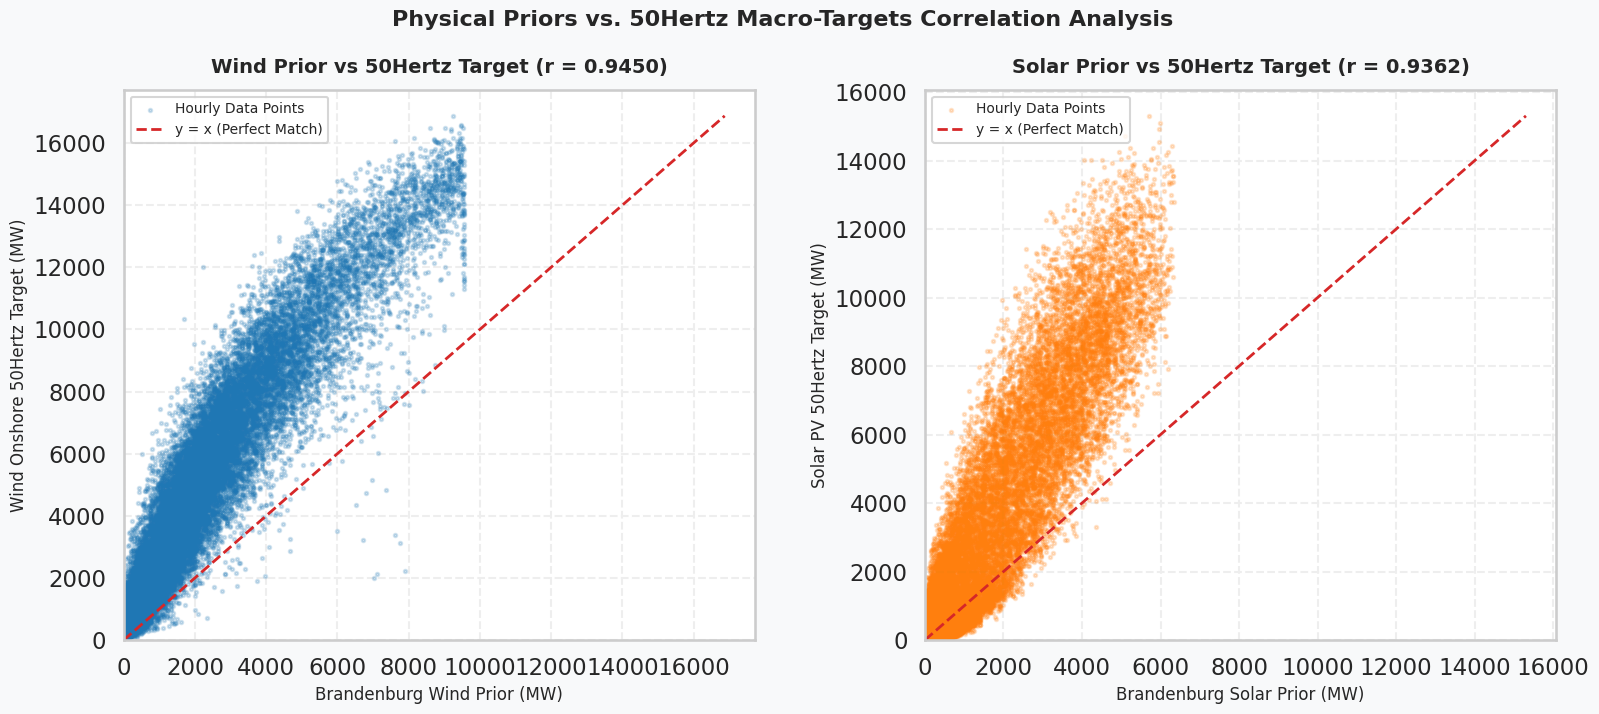

In [2]:
# Create 1x2 subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 7), sharey=False)

# Left Panel: Wind Prior vs Wind Target
wind_prior = df['brandenburg_wind_prior_mw']
wind_target = df['wind_onshore_mw_50hz']
r_wind, p_wind = pearsonr(wind_prior, wind_target)

# We use low alpha and small marker size to handle high point density cleanly
axes[0].scatter(wind_prior, wind_target, alpha=0.2, color='#1f77b4', s=6, label='Hourly Data Points')
max_wind = max(wind_prior.max(), wind_target.max())
axes[0].plot([0, max_wind], [0, max_wind], color='#d62728', linestyle='--', linewidth=2, label='y = x (Perfect Match)')
axes[0].set_title(f"Wind Prior vs 50Hertz Target (r = {r_wind:.4f})", fontsize=14, pad=12, weight='bold')
axes[0].set_xlabel("Brandenburg Wind Prior (MW)", fontsize=12)
axes[0].set_ylabel("Wind Onshore 50Hertz Target (MW)", fontsize=12)
axes[0].legend(fontsize=10, loc='upper left')
axes[0].set_xlim(0, max_wind * 1.05)
axes[0].set_ylim(0, max_wind * 1.05)

# Right Panel: Solar Prior vs Solar Target
solar_prior = df['brandenburg_solar_prior_mw']
solar_target = df['solar_pv_mw_50hz']
r_solar, p_solar = pearsonr(solar_prior, solar_target)

axes[1].scatter(solar_prior, solar_target, alpha=0.2, color='#ff7f0e', s=6, label='Hourly Data Points')
max_solar = max(solar_prior.max(), solar_target.max())
axes[1].plot([0, max_solar], [0, max_solar], color='#d62728', linestyle='--', linewidth=2, label='y = x (Perfect Match)')
axes[1].set_title(f"Solar Prior vs 50Hertz Target (r = {r_solar:.4f})", fontsize=14, pad=12, weight='bold')
axes[1].set_xlabel("Brandenburg Solar Prior (MW)", fontsize=12)
axes[1].set_ylabel("Solar PV 50Hertz Target (MW)", fontsize=12)
axes[1].legend(fontsize=10, loc='upper left')
axes[1].set_xlim(0, max_solar * 1.05)
axes[1].set_ylim(0, max_solar * 1.05)

plt.tight_layout()
fig.suptitle("Physical Priors vs. 50Hertz Macro-Targets Correlation Analysis", fontsize=16, y=1.03, weight='bold')
plt.show()

## 3. Time-Series Tracking: Phase Alignment

To ensure there is no timezone mismatch or look-ahead bias in our preprocessing pipelines, we slice a 14-day window in May 2024 and plot the physical prior alongside the true 50Hertz actual generation for Solar PV.
Solar peaks must align precisely with daily solar noon (accounting for seasonal shifting in UTC).

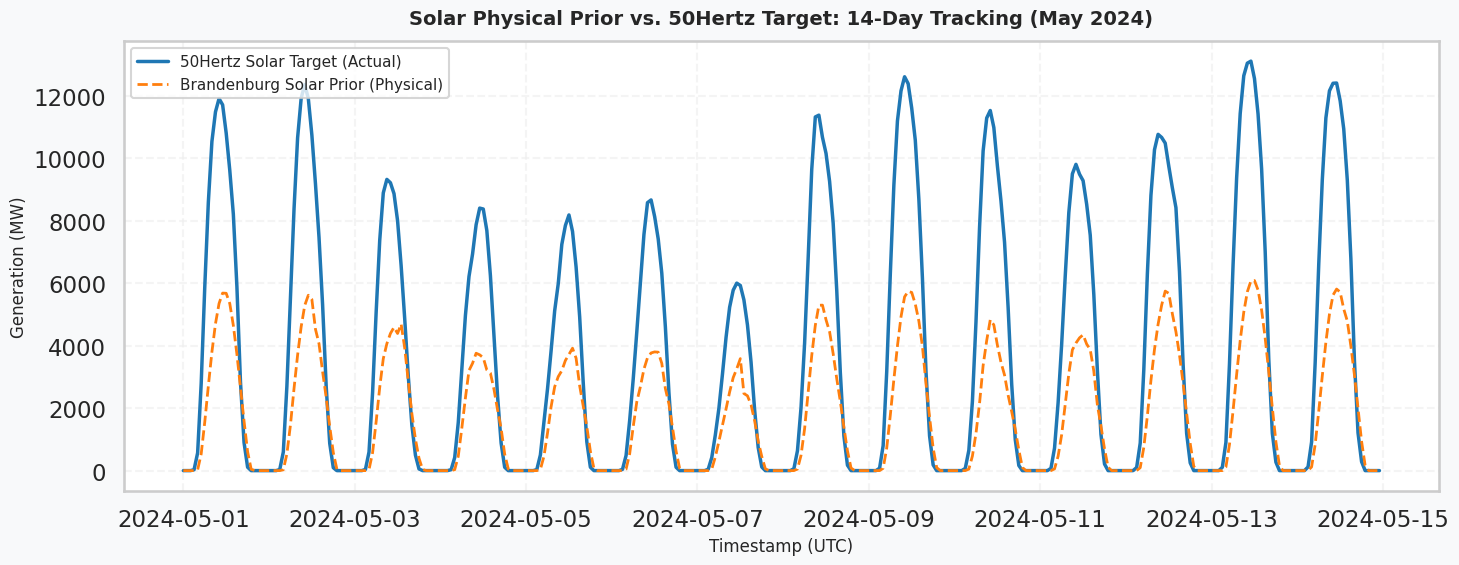

In [3]:
# Define the 14-day slice range in May 2024
start_date = '2024-05-01 00:00:00'
end_date = '2024-05-14 23:59:59'

# Safely mask the dataframe using timezone comparison strings
df_slice = df[(df.index >= start_date) & (df.index <= end_date)]

plt.figure(figsize=(15, 6))
plt.plot(df_slice.index, df_slice['solar_pv_mw_50hz'], label='50Hertz Solar Target (Actual)', color='#1f77b4', linewidth=2.5)
plt.plot(df_slice.index, df_slice['brandenburg_solar_prior_mw'], label='Brandenburg Solar Prior (Physical)', color='#ff7f0e', linestyle='--', linewidth=2)

plt.title("Solar Physical Prior vs. 50Hertz Target: 14-Day Tracking (May 2024)", fontsize=14, pad=12, weight='bold')
plt.xlabel("Timestamp (UTC)", fontsize=12)
plt.ylabel("Generation (MW)", fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Residual Diagnostic: Weather Dependency Analysis

We calculate the residual wind error:
$$e_{wind, t} = y_{target, t} - \hat{y}_{prior, t}$$

We then compute the Pearson correlation matrix of the error against meteorological features:
- `temperature_2m`
- `surface_pressure`
- `relative_humidity_2m`

This heatmap helps us understand what physical dependencies are left uncaptured by the basic power curve conversion (e.g. pressure variations changing air density $\rho$, temperature impacting turbine cooling or solar PV efficiency).

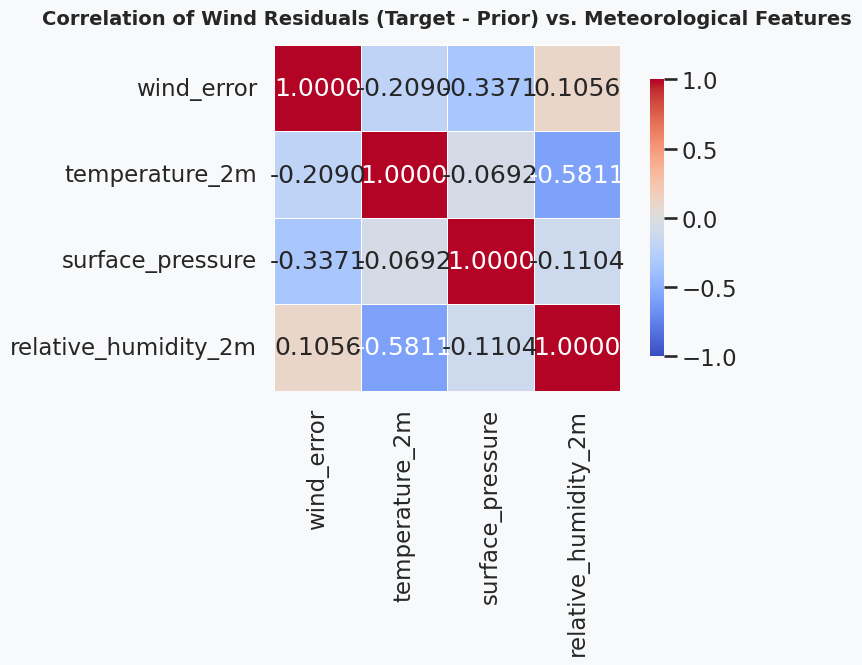

In [4]:
# Calculate wind error residuals
df['wind_error'] = df['wind_onshore_mw_50hz'] - df['brandenburg_wind_prior_mw']

# Select variables of interest
corr_cols = ['wind_error', 'temperature_2m', 'surface_pressure', 'relative_humidity_2m']
corr_matrix = df[corr_cols].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    cmap='coolwarm', 
    vmin=-1.0, 
    vmax=1.0, 
    fmt=".4f", 
    square=True, 
    linewidths=.5,
    cbar_kws={"shrink": .8}
)
plt.title("Correlation of Wind Residuals (Target - Prior) vs. Meteorological Features", fontsize=14, pad=15, weight='bold')
plt.tight_layout()
plt.show()